SISTECH 2026 — MLOps Hands-On 2

## Membangun Mesin Prediksi & Continual Learning untuk Risk Score

1.  Load dataset fitur 
2.  **Baseline non-ML** — patokan minimal sebelum melatih model apa pun
3.  **Feature Vector Assembly** — merakit fitur jadi input yang
    konsisten
4.  **Model regresi** — melatih model untuk memprediksi Risk Score
5.  **Evaluasi model** — dibandingkan eksplisit dengan baseline
6.  **Simulasi continual learning** — data datang bertahap dalam
    beberapa batch
7.  **Drift detection** — mendeteksi kapan data baru “berbeda” secara
    signifikan
8.  **Checkpoint retraining & model versioning** — retrain bersyarat +
    rekam jejak model

# 0. Installation & Setup

In [1]:
import os
import json
import hashlib
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
np.random.seed(42)
print("Setup selesai ✅")

Setup selesai ✅


# 1. Load Dataset Fitur + Label dari Hands-On 1

In [2]:
DATA_PATH = "../data/dataset/features_labels.csv" 

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset dari Hands-On 1 berhasil dimuat: {df.shape}")
else:
    print(f"'{DATA_PATH}' tidak ditemukan. Membuat dataset SINTETIS untuk demo notebook...")
    rng = np.random.default_rng(0)
    n_cells = 150
    lat_r = rng.uniform(41.65, 42.00, n_cells).round(2)
    lon_r = rng.uniform(-87.90, -87.55, n_cells).round(2)
    cell_ids = [f"{la}_{lo}" for la, lo in zip(lat_r, lon_r)]

    rows = []
    for cid, la, lo in zip(cell_ids, lat_r, lon_r):
        for dow in range(7):
            for hour in range(0, 24, 3):  # subset jam biar ringkas
                crime_count = rng.poisson(3) + 1
                base = 10 + 40 * (np.sin(np.deg2rad(hour * 15)) + 1) / 2
                base += 15 * (1 if dow >= 5 else 0)
                base += crime_count * 1.5
                risk_score = float(np.clip(base + rng.normal(0, 5), 0, 100))
                rows.append({
                    "cell_id": cid, "lat_r": la, "lon_r": lo,
                    "dow": dow, "hour": hour,
                    "hour_sin": np.sin(2*np.pi*hour/24), "hour_cos": np.cos(2*np.pi*hour/24),
                    "dow_sin": np.sin(2*np.pi*dow/7), "dow_cos": np.cos(2*np.pi*dow/7),
                    "crime_count": crime_count, "risk_score": risk_score,
                })
    df = pd.DataFrame(rows)
    print(f"Dataset sintetis dibuat: {df.shape}")

df.head()

Dataset dari Hands-On 1 berhasil dimuat: (119454, 12)


,cell_id,lat_r,lon_r,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,crime_count,arrest_rate,risk_score
0,-6.11_106.69,-6.11,106.69,0,0,0.000000,1.00000,0.000000e+00,1.000000,1,0.0,34.989507
1,-6.11_106.69,-6.11,106.69,0,3,0.000000,1.00000,7.071068e-01,0.707107,1,0.0,28.500710
2,-6.11_106.69,-6.11,106.69,0,12,0.000000,1.00000,1.224647e-16,-1.000000,3,0.0,23.418378
3,-6.11_106.69,-6.11,106.69,0,15,0.000000,1.00000,-7.071068e-01,-0.707107,1,0.0,10.415326
4,-6.11_106.69,-6.11,106.69,1,9,0.781831,0.62349,7.071068e-01,-0.707107,1,0.0,37.168742


In [3]:
df.describe().round(2)

,lat_r,lon_r,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,crime_count,arrest_rate,risk_score
count,119454.00,119454.00,119454.0,119454.00,119454.00,119454.00,119454.00,119454.00,119454.00,119454.00,119454.00
mean,-6.32,106.86,3.0,11.82,-0.00,-0.00,-0.05,-0.01,4.61,0.13,60.08
std,0.12,0.08,2.0,6.92,0.71,0.71,0.70,0.71,4.80,0.22,13.40
min,-6.55,106.55,0.0,0.00,-0.97,-0.90,-1.00,-1.00,1.00,0.00,0.00
25%,-6.41,106.81,1.0,6.00,-0.78,-0.90,-0.71,-0.71,2.00,0.00,52.09
50%,-6.32,106.87,3.0,12.00,0.00,-0.22,0.00,-0.00,3.00,0.00,61.84
75%,-6.22,106.92,5.0,18.00,0.78,0.62,0.71,0.71,6.00,0.20,69.98
max,-6.10,107.05,6.0,23.00,0.97,1.00,1.00,1.00,115.00,1.00,100.00


### Distribusi Risk Score


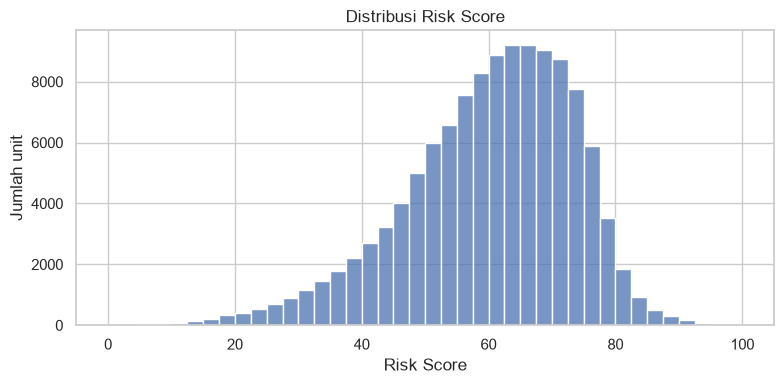

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df["risk_score"], bins=40, color="#4C72B0")
plt.title("Distribusi Risk Score")
plt.xlabel("Risk Score"); plt.ylabel("Jumlah unit")
plt.tight_layout(); plt.show()

# 2. Baseline Non-ML — Historical Average

In [5]:
TARGET_COL = "risk_score"

# Split evaluasi: 80% train, 20% test (acak, untuk evaluasi model & baseline statis)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"train_df: {train_df.shape}  |  test_df: {test_df.shape}")

train_df: (95563, 12)  |  test_df: (23891, 12)


In [6]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

# --- Baseline 1: global mean ---
global_mean = train_df[TARGET_COL].mean()
pred_global = np.full(len(test_df), global_mean)
results.append(evaluate(test_df[TARGET_COL], pred_global, "Baseline: Global Mean"))

# --- Baseline 2: rata-rata per sel (pola spasial) ---
cell_mean_map = train_df.groupby("cell_id")[TARGET_COL].mean()
pred_cell = test_df["cell_id"].map(cell_mean_map).fillna(global_mean).values
results.append(evaluate(test_df[TARGET_COL], pred_cell, "Baseline: Rata-rata per Sel"))

# --- Baseline 3: rata-rata per (hari, jam) (pola temporal) ---
hourdow_mean_map = train_df.groupby(["dow", "hour"])[TARGET_COL].mean()
idx = pd.MultiIndex.from_frame(test_df[["dow", "hour"]])
pred_hourdow = hourdow_mean_map.reindex(idx).values
pred_hourdow = np.where(np.isnan(pred_hourdow), global_mean, pred_hourdow)
results.append(evaluate(test_df[TARGET_COL], pred_hourdow, "Baseline: Rata-rata per Jam+Hari"))

baseline_results_df = pd.DataFrame(results)
baseline_results_df.round(3)

,model,MAE,RMSE,R2
0,Baseline: Global Mean,10.646,13.439,-0.000
1,Baseline: Rata-rata per Sel,5.653,7.157,0.716
2,Baseline: Rata-rata per Jam+Hari,9.606,12.425,0.145


In [7]:
# Kombinasi pola: (cell_id, hour) dan (cell_id, dow), dengan fallback berjenjang.
# Fallback: kombinasi -> rata-rata per cell_id -> rata-rata per (dow, hour) -> global mean

def _map_with_fallback(test_series_df, group_cols, train_df, target_col, fallback_series):
    """Prediksi via rata-rata grup train_df[group_cols], fallback ke fallback_series bila NaN."""
    group_mean = train_df.groupby(group_cols)[target_col].mean()
    if len(group_cols) == 1:
        idx = test_series_df[group_cols[0]]
        pred = idx.map(group_mean)
    else:
        idx = pd.MultiIndex.from_frame(test_series_df[group_cols])
        pred = pd.Series(group_mean.reindex(idx).values, index=test_series_df.index)
    return pred.fillna(fallback_series).values

# --- Baseline 4: kombinasi (cell_id, hour) ---
pred_cell_hour = _map_with_fallback(
    test_df, ["cell_id", "hour"], train_df, TARGET_COL, pd.Series(global_mean, index=test_df.index)
)
results.append(evaluate(test_df[TARGET_COL], pred_cell_hour, "Baseline: Rata-rata per (Sel, Jam)"))

# --- Baseline 5: kombinasi (cell_id, dow), fallback ke rata-rata per sel dulu, baru global ---
fallback_cell = test_df["cell_id"].map(cell_mean_map).fillna(global_mean)
pred_cell_dow = _map_with_fallback(
    test_df, ["cell_id", "dow"], train_df, TARGET_COL, fallback_cell
)
results.append(evaluate(test_df[TARGET_COL], pred_cell_dow, "Baseline: Rata-rata per (Sel, Hari)"))

baseline_results_df = pd.DataFrame(results)
baseline_results_df.round(3)

,model,MAE,RMSE,R2
0,Baseline: Global Mean,10.646,13.439,-0.000
1,Baseline: Rata-rata per Sel,5.653,7.157,0.716
2,Baseline: Rata-rata per Jam+Hari,9.606,12.425,0.145
3,"Baseline: Rata-rata per (Sel, Jam)",4.071,6.072,0.796
4,"Baseline: Rata-rata per (Sel, Hari)",5.890,7.443,0.693


# 3. Feature Vector Assembly

Fitur `cell_freq_enc` (frekuensi kemunculan sel) dan `cell_target_enc`
(rata-rata `risk_score` per sel - *target encoding*) butuh perhatian
khusus terhadap leakage:

-   `cell_freq_enc` **aman** dihitung dari statistik training penuh
    (bukan turunan dari target).
-   `cell_target_enc` **wajib** dihitung *out-of-fold* saat training -
    supaya setiap baris tidak pernah “melihat” `risk_score`-nya sendiri
    lewat rata-rata kelompoknya - dan memakai peta yang di-fit dari data
    training terkait saat dipakai untuk evaluasi/serving.

In [8]:
FEATURE_COLS = [
    "lat_r", "lon_r",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "crime_count",
]

def fit_encoding_maps(data, target_col=TARGET_COL, global_fallback=None):
    """Fit statistik encoding cell_id HANYA dari `data` yang diberikan.
    Dipakai untuk menyiapkan `maps` dari suatu training subset (train_df awal
    ATAU cumulative_train saat continual learning) SEBELUM dipakai untuk
    merakit fitur pada data lain (test/holdout/serving)."""
    freq_map = data["cell_id"].value_counts(normalize=True)
    target_map = data.groupby("cell_id")[target_col].mean()
    fallback = global_fallback if global_fallback is not None else data[target_col].mean()
    return {"freq_map": freq_map, "target_map": target_map, "global_fallback": fallback}


def assemble_features(data, maps, feature_cols=FEATURE_COLS):
    """Merakit feature vector untuk data NON-TRAINING (test/holdout/serving),
    memakai `maps` yang sudah di-fit dari data training terkait
    (lihat fit_encoding_maps). JANGAN dipakai untuk merakit fitur TRAINING —
    pakai assemble_features_train_oof supaya cell_target_enc aman dari leakage."""
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Kolom fitur berikut tidak ditemukan di data: {missing}")

    X = data[feature_cols].copy()
    X["cell_freq_enc"] = data["cell_id"].map(maps["freq_map"]).fillna(0.0)
    X["cell_target_enc"] = data["cell_id"].map(maps["target_map"]).fillna(maps["global_fallback"])
    return X


def assemble_features_train_oof(data, feature_cols=FEATURE_COLS, target_col=TARGET_COL,
                                 n_splits=5, random_state=42):
    """Versi khusus TRAIN: cell_target_enc dihitung out-of-fold dari `data` itu
    sendiri, supaya baris tidak pernah 'melihat' targetnya sendiri lewat encoding.
    cell_freq_enc tetap boleh pakai statistik `data` utuh (bukan turunan target,
    jadi aman).

    Return: (X, maps) — `maps` WAJIB dipakai lagi lewat assemble_features() saat
    mengevaluasi model yang dilatih dari `data` ini di data lain (test/holdout).
    """
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Kolom fitur berikut tidak ditemukan di data: {missing}")

    X = data[feature_cols].copy()

    maps = fit_encoding_maps(data, target_col=target_col)
    X["cell_freq_enc"] = data["cell_id"].map(maps["freq_map"]).fillna(0.0)

    # cell_target_enc: OUT-OF-FOLD
    oof_enc = pd.Series(index=data.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for fit_idx, hold_idx in kf.split(data):
        fit_part = data.iloc[fit_idx]
        hold_part = data.iloc[hold_idx]

        fold_target_map = fit_part.groupby("cell_id")[target_col].mean()
        fold_fallback = fit_part[target_col].mean()  # fallback lokal ke fold ini

        oof_enc.iloc[hold_idx] = (
            hold_part["cell_id"].map(fold_target_map).fillna(fold_fallback).values
        )

    X["cell_target_enc"] = oof_enc.values
    return X, maps


# --- TRAIN (split statis Bagian 2): pakai versi out-of-fold ---
X_train, train_maps = assemble_features_train_oof(train_df)
y_train = train_df[TARGET_COL].values

# --- TEST / SERVING: pakai maps yang di-fit dari train_df (bukan dari test_df) ---
X_test = assemble_features(test_df, train_maps)
y_test = test_df[TARGET_COL].values

FEATURE_COLS_FINAL = list(X_train.columns)
print("Shape X_train:", X_train.shape, "| Shape X_test:", X_test.shape)
X_train.head()

Shape X_train: (95563, 9) | Shape X_test: (23891, 9)


,lat_r,lon_r,hour_sin,hour_cos,dow_sin,dow_cos,crime_count,cell_freq_enc,cell_target_enc
0,-6.35,106.78,0.500000,0.866025,-0.974928,-0.222521,3,0.001109,43.193322
1,-6.16,106.60,0.258819,0.965926,-0.974928,-0.222521,2,0.001256,34.920079
2,-6.36,106.96,0.707107,-0.707107,-0.781831,0.623490,1,0.001455,68.920190
3,-6.22,106.75,0.000000,1.000000,0.974928,-0.222521,5,0.001319,60.548877
4,-6.50,107.03,0.258819,0.965926,0.974928,-0.222521,1,0.000576,38.312432


In [9]:
# Cek korelasi tiap fitur terhadap risk_score (sanity check relevansi fitur)
corr_check = X_train.copy()
corr_check[TARGET_COL] = y_train
corr_with_target = corr_check.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
print("Korelasi fitur terhadap risk_score:")
print(corr_with_target.round(3))

Korelasi fitur terhadap risk_score:
cell_target_enc    0.841
cell_freq_enc      0.556
crime_count        0.541
lon_r              0.353
hour_sin          -0.300
hour_cos          -0.048
dow_sin           -0.032
dow_cos           -0.012
lat_r              0.007
Name: risk_score, dtype: float64


# 4. Regression Model — Training

In [10]:
# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_model = lr_model.predict(X_test)
results.append(evaluate(y_test, y_pred_model, "Model: Linear Regression"))

coef_df = pd.DataFrame({"feature": FEATURE_COLS_FINAL, "coefficient": lr_model.coef_}).sort_values(
    "coefficient", key=abs, ascending=False
)
coef_df

,feature,coefficient
7,cell_freq_enc,214.838904
2,hour_sin,-5.938171
3,hour_cos,-0.980767
8,cell_target_enc,0.935058
0,lat_r,-0.665910
4,dow_sin,-0.606933
1,lon_r,0.543348
6,crime_count,0.365905
5,dow_cos,-0.236067


In [11]:
# --- Model 2: Random Forest (menangkap non-linearitas & interaksi fitur) ---
rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=None, min_samples_leaf=3,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate(y_test, y_pred_rf, "Model: Random Forest"))

# --- Model 3: Gradient Boosting (pembanding lain berbasis pohon) ---
gbm_model = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
)
gbm_model.fit(X_train, y_train)
y_pred_gbm = gbm_model.predict(X_test)
results.append(evaluate(y_test, y_pred_gbm, "Model: Gradient Boosting"))

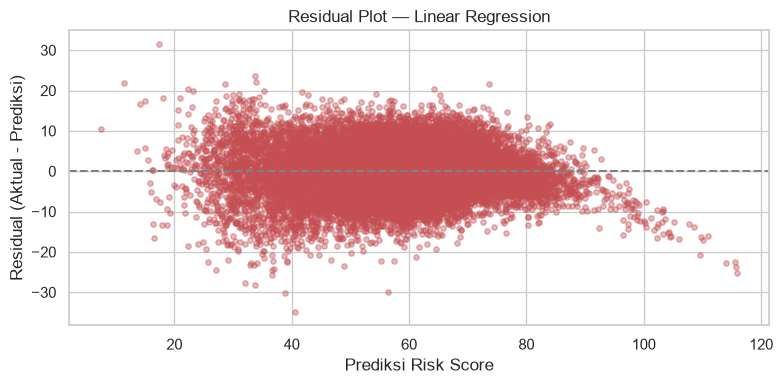

In [12]:
# Cek asumsi linearitas: plot residual model Linear Regression
residuals_lr = y_test - y_pred_model
plt.figure(figsize=(8, 4))
plt.scatter(y_pred_model, residuals_lr, alpha=0.4, s=15, color="#C44E52")
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Prediksi Risk Score"); plt.ylabel("Residual (Aktual - Prediksi)")
plt.title("Residual Plot — Linear Regression")
plt.tight_layout(); plt.show()

# 5. Model Evaluation vs Baseline

In [13]:
final_results_df = pd.DataFrame(results).round(3)
final_results_df

,model,MAE,RMSE,R2
0,Baseline: Global Mean,10.646,13.439,-0.000
1,Baseline: Rata-rata per Sel,5.653,7.157,0.716
2,Baseline: Rata-rata per Jam+Hari,9.606,12.425,0.145
3,"Baseline: Rata-rata per (Sel, Jam)",4.071,6.072,0.796
4,"Baseline: Rata-rata per (Sel, Hari)",5.890,7.443,0.693
5,Model: Linear Regression,4.076,5.369,0.840
6,Model: Random Forest,2.717,3.733,0.923
7,Model: Gradient Boosting,3.063,4.120,0.906


In [14]:
feature_importance_df = pd.DataFrame({
    "feature": FEATURE_COLS_FINAL,
    "importance_rf": rf_model.feature_importances_,
}).sort_values("importance_rf", ascending=False)
feature_importance_df

,feature,importance_rf
8,cell_target_enc,0.743396
2,hour_sin,0.133728
3,hour_cos,0.045847
4,dow_sin,0.022483
6,crime_count,0.017468
1,lon_r,0.011618
0,lat_r,0.011358
7,cell_freq_enc,0.008676
5,dow_cos,0.005427


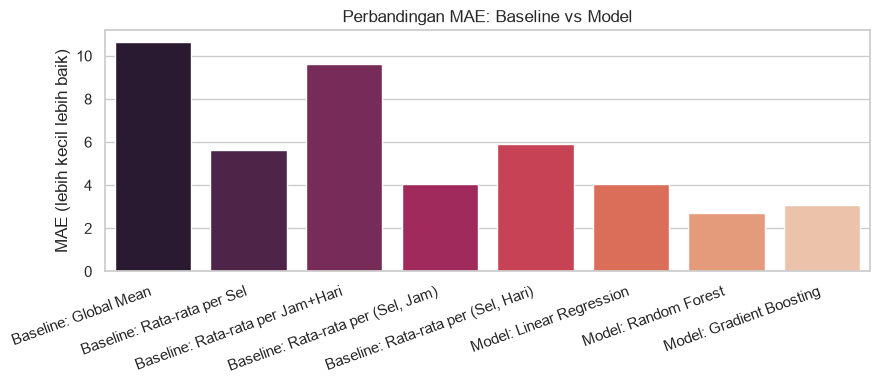

In [15]:
plt.figure(figsize=(9, 4))
sns.barplot(data=final_results_df, x="model", y="MAE", hue="model", palette="rocket", legend=False)
plt.title("Perbandingan MAE: Baseline vs Model")
plt.ylabel("MAE (lebih kecil lebih baik)"); plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

Model terbaik: Model: Random Forest


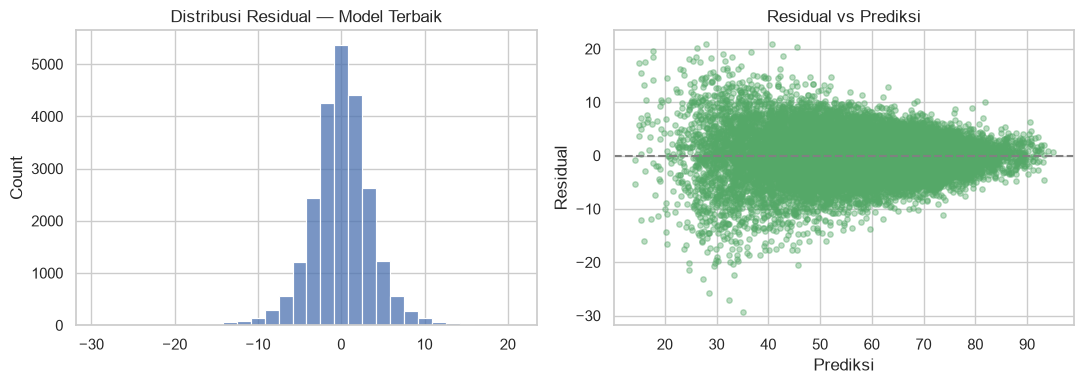

In [16]:
# Pilih model terbaik (MAE terkecil) sebagai fokus analisis residual & segmen
best_model_row = final_results_df.loc[final_results_df["model"].str.startswith("Model:")].sort_values("MAE").iloc[0]
print("Model terbaik:", best_model_row["model"])

best_pred_map = {"Model: Linear Regression": y_pred_model, "Model: Random Forest": y_pred_rf,
                  "Model: Gradient Boosting": y_pred_gbm}
y_pred_best = best_pred_map[best_model_row["model"]]
residuals_best = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(residuals_best, bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribusi Residual — Model Terbaik")
axes[1].scatter(y_pred_best, residuals_best, alpha=0.4, s=15, color="#55A868")
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set_xlabel("Prediksi"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residual vs Prediksi")
plt.tight_layout(); plt.show()

# 6. Simulasi Continual Learning — Data Datang Bertahap

Dataset `features_labels.csv` adalah hasil agregasi Hands-On 1 (per `cell_id`,
`dow`, `hour`) sehingga tidak menyimpan timestamp mentah per baris kejahatan.
Untuk mensimulasikan "data baru yang datang seiring waktu" seperti yang diminta
task Final Project, holdout `test_df` (yang sama sekali belum dilihat model
manapun) dipecah menjadi beberapa **batch** berurutan. Setiap batch mewakili
satu periode data baru yang tiba setelah model checkpoint pertama (`v1`)
di-deploy.

Ini adalah simulasi, bukan urutan waktu historis asli — pendekatan ini
eksplisit diizinkan oleh brief task ("disimulasikan dari temporal split").

In [17]:
from pathlib import Path

N_BATCHES = 4
_shuffled_holdout = test_df.sample(frac=1.0, random_state=7).reset_index(drop=True)
_boundaries = np.array_split(np.arange(len(_shuffled_holdout)), N_BATCHES)
batch_dfs = [_shuffled_holdout.iloc[idx].reset_index(drop=True) for idx in _boundaries]

for i, b in enumerate(batch_dfs, start=1):
    print(f"Batch {i}: {len(b)} baris (simulasi periode data baru ke-{i})")

Batch 1: 5973 baris (simulasi periode data baru ke-1)
Batch 2: 5973 baris (simulasi periode data baru ke-2)
Batch 3: 5973 baris (simulasi periode data baru ke-3)
Batch 4: 5972 baris (simulasi periode data baru ke-4)


# 7. Drift Detection

Dua sinyal drift dicek untuk tiap batch, terhadap model & data referensi yang
sedang aktif:

1.  **Performance drift** — MAE model aktif pada batch dibanding MAE baseline
    test set (`v1`). Jika naik melewati rasio ambang (`MAE_THRESHOLD_RATIO`),
    ini indikasi performa mulai turun.
2.  **Distribution drift** — uji Kolmogorov–Smirnov (`ks_2samp`) pada beberapa
    fitur numerik kunci (`crime_count`, `lat_r`, `lon_r`), membandingkan
    distribusi batch vs data training kumulatif saat ini. p-value kecil
    (< `KS_ALPHA`) menandakan distribusi sudah bergeser signifikan.

Batch dianggap "drift" jika **salah satu** dari kedua sinyal ini terpicu.

In [18]:
def check_performance_drift(y_true, y_pred, baseline_mae, threshold_ratio=1.3):
    """Bandingkan MAE batch terhadap baseline MAE test set model aktif."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    drifted = mae > baseline_mae * threshold_ratio
    return {
        "mae": float(mae), "rmse": float(rmse),
        "baseline_mae": float(baseline_mae), "threshold_ratio": threshold_ratio,
        "performance_drift": bool(drifted),
    }


def check_distribution_drift(batch_df, reference_df, features, alpha=0.05):
    """Uji KS dua sampel per fitur: distribusi batch vs data referensi (training kumulatif)."""
    flags = {}
    for f in features:
        stat, p_value = ks_2samp(reference_df[f].dropna(), batch_df[f].dropna())
        flags[f] = {"ks_stat": float(stat), "p_value": float(p_value), "drift": bool(p_value < alpha)}
    any_drift = any(v["drift"] for v in flags.values())
    return {"per_feature": flags, "distribution_drift": bool(any_drift)}


def evaluate_batch(batch_df, active_model, active_maps, reference_df, baseline_mae,
                    ks_features, mae_threshold_ratio=1.3, ks_alpha=0.05):
    """Gabungkan performance drift + distribution drift untuk satu batch data baru."""
    X_b = assemble_features(batch_df, active_maps)
    y_b = batch_df[TARGET_COL].values
    y_pred_b = active_model.predict(X_b)

    perf = check_performance_drift(y_b, y_pred_b, baseline_mae, mae_threshold_ratio)
    dist = check_distribution_drift(batch_df, reference_df, ks_features, ks_alpha)

    return {
        "performance": perf, "distribution": dist,
        "drift_detected": bool(perf["performance_drift"] or dist["distribution_drift"]),
        "n_rows": int(len(batch_df)),
    }

# 8. Checkpoint Retraining & Model Versioning

Setiap kali drift terdeteksi pada suatu batch:

1.  Batch digabung ke `cumulative_train`.
2.  Model kandidat baru dilatih ulang dari `cumulative_train` (encoding map
    di-*refit*, `cell_target_enc` tetap dihitung out-of-fold agar tidak leak).
3.  **Quality gate**: model kandidat dievaluasi pada `test_df` yang sama dan
    dibandingkan terhadap model aktif saat ini. Kandidat hanya **dipromosikan**
    (menggantikan model aktif) jika MAE-nya tidak lebih buruk.
4.  Checkpoint (model + encoding maps + metadata) disimpan sebagai versi baru
    di `model_registry/`, apa pun hasil promosinya — supaya setiap upaya
    retraining tetap tercatat & bisa ditelusuri/di-*rollback*.
5.  `active_version.json` dan `version_history.json` diperbarui — inilah yang
    akan dibaca REST API untuk mengisi field `model_version` dan `last_updated`.

In [19]:
MODEL_REGISTRY_DIR = Path("../model_registry")
MODEL_REGISTRY_DIR.mkdir(parents=True, exist_ok=True)


def next_version_number(registry_dir=MODEL_REGISTRY_DIR):
    existing = [int(p.name[1:]) for p in registry_dir.glob("v*")
                if p.is_dir() and p.name[1:].isdigit()]
    return (max(existing) + 1) if existing else 1


def save_checkpoint(model, maps, feature_cols, metrics, trigger="initial_training",
                     parent_version=None, n_train_rows=None, registry_dir=MODEL_REGISTRY_DIR):
    """Simpan model + encoding maps + metadata sebagai versi baru di model registry,
    dan tambahkan ke version_history.json (dibaca REST API)."""
    version_id = f"v{next_version_number(registry_dir)}"
    version_dir = registry_dir / version_id
    version_dir.mkdir(parents=True, exist_ok=True)

    joblib.dump(model, version_dir / "model.pkl")
    joblib.dump(maps, version_dir / "encoding_maps.pkl")

    metadata = {
        "version": version_id,
        "trained_at": datetime.now(timezone.utc).isoformat(),
        "n_train_rows": n_train_rows,
        "feature_cols": feature_cols,
        "metrics": metrics,
        "trigger": trigger,
        "parent_version": parent_version,
    }
    with open(version_dir / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    history_path = registry_dir / "version_history.json"
    history = json.load(open(history_path)) if history_path.exists() else []
    history.append(metadata)
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    return version_id, metadata


def set_active_version(version_id, registry_dir=MODEL_REGISTRY_DIR):
    """Tandai versi mana yang sedang \'live\' — dibaca API saat startup/predict."""
    with open(registry_dir / "active_version.json", "w") as f:
        json.dump(
            {"active_version": version_id, "updated_at": datetime.now(timezone.utc).isoformat()},
            f, indent=2,
        )

In [20]:
# --- Checkpoint awal (v1) = model Random Forest yang sudah dilatih di Bagian 4 ---
PROD_BASELINE_MAE = float(mean_absolute_error(y_test, y_pred_rf))
PROD_BASELINE_RMSE = float(np.sqrt(mean_squared_error(y_test, y_pred_rf)))

cumulative_train = train_df.copy()
active_model = rf_model
active_maps = train_maps

active_version, v1_meta = save_checkpoint(
    model=active_model, maps=active_maps, feature_cols=FEATURE_COLS_FINAL,
    metrics={"mae_test": PROD_BASELINE_MAE, "rmse_test": PROD_BASELINE_RMSE, "n_test_rows": int(len(test_df))},
    trigger="initial_training", parent_version=None, n_train_rows=int(len(train_df)),
)
set_active_version(active_version)

print(f"Checkpoint awal disimpan sebagai {active_version} | MAE test: {PROD_BASELINE_MAE:.3f}")

Checkpoint awal disimpan sebagai v4 | MAE test: 2.717


In [21]:
MAE_THRESHOLD_RATIO = 1.3     # retrain jika MAE batch > 1.3x MAE baseline (v1)
KS_ALPHA = 0.05
KS_FEATURES = ["crime_count", "lat_r", "lon_r"]

drift_log = []

for i, batch_df in enumerate(batch_dfs, start=1):
    print(f"\n=== Batch {i}/{len(batch_dfs)} ({len(batch_df)} baris) | model aktif: {active_version} ===")

    report = evaluate_batch(
        batch_df, active_model, active_maps, reference_df=cumulative_train,
        baseline_mae=PROD_BASELINE_MAE, ks_features=KS_FEATURES,
        mae_threshold_ratio=MAE_THRESHOLD_RATIO, ks_alpha=KS_ALPHA,
    )
    report.update({"batch": i, "active_version_before": active_version, "candidate_version": None, "promoted": False})

    print(f"  MAE batch: {report['performance']['mae']:.3f} "
          f"(baseline: {PROD_BASELINE_MAE:.3f}, ambang: {PROD_BASELINE_MAE * MAE_THRESHOLD_RATIO:.3f})")
    print(f"  Performance drift: {report['performance']['performance_drift']} | "
          f"Distribution drift: {report['distribution']['distribution_drift']}")

    if report["drift_detected"]:
        print("  -> Drift terdeteksi. Retraining checkpoint baru dari data kumulatif...")
        cumulative_train = pd.concat([cumulative_train, batch_df], ignore_index=True)
        X_cum, cum_maps = assemble_features_train_oof(cumulative_train)
        y_cum = cumulative_train[TARGET_COL].values

        candidate_model = RandomForestRegressor(
            n_estimators=300, max_depth=None, min_samples_leaf=3, random_state=42, n_jobs=-1
        )
        candidate_model.fit(X_cum, y_cum)

        # --- Quality gate: uji kandidat & model aktif pada test_df yang sama ---
        mae_cand = mean_absolute_error(y_test, candidate_model.predict(assemble_features(test_df, cum_maps)))
        mae_active_now = mean_absolute_error(y_test, active_model.predict(assemble_features(test_df, active_maps)))
        promoted = mae_cand <= mae_active_now
        trigger_reason = "performance_drift" if report["performance"]["performance_drift"] else "distribution_drift"

        new_version, _ = save_checkpoint(
            model=candidate_model, maps=cum_maps, feature_cols=FEATURE_COLS_FINAL,
            metrics={"mae_test": float(mae_cand), "mae_before_retrain": float(mae_active_now)},
            trigger=trigger_reason, parent_version=active_version, n_train_rows=int(len(cumulative_train)),
        )
        report["candidate_version"] = new_version
        report["promoted"] = bool(promoted)

        if promoted:
            active_model, active_maps, active_version = candidate_model, cum_maps, new_version
            set_active_version(active_version)
            print(f"  -> {new_version} DIPROMOSIKAN (MAE {mae_cand:.3f} <= {mae_active_now:.3f})")
        else:
            print(f"  -> {new_version} disimpan tapi TIDAK dipromosikan "
                  f"(MAE {mae_cand:.3f} > {mae_active_now:.3f}); tetap pakai {active_version}")
    else:
        print("  -> Tidak ada drift signifikan. Model aktif dipertahankan, tidak retrain.")

    report["active_version_after"] = active_version
    drift_log.append(report)

# Simpan log drift & retraining — dipakai untuk basic monitoring & endpoint API
with open(MODEL_REGISTRY_DIR / "drift_log.json", "w") as f:
    json.dump(drift_log, f, indent=2, default=str)

print(f"\nModel aktif akhir: {active_version}")
print(f"Log drift disimpan ke: {(MODEL_REGISTRY_DIR / 'drift_log.json').resolve()}")


=== Batch 1/4 (5973 baris) | model aktif: v4 ===
  MAE batch: 2.758 (baseline: 2.717, ambang: 3.532)
  Performance drift: False | Distribution drift: False
  -> Tidak ada drift signifikan. Model aktif dipertahankan, tidak retrain.

=== Batch 2/4 (5973 baris) | model aktif: v4 ===
  MAE batch: 2.694 (baseline: 2.717, ambang: 3.532)
  Performance drift: False | Distribution drift: False
  -> Tidak ada drift signifikan. Model aktif dipertahankan, tidak retrain.

=== Batch 3/4 (5973 baris) | model aktif: v4 ===
  MAE batch: 2.730 (baseline: 2.717, ambang: 3.532)
  Performance drift: False | Distribution drift: False
  -> Tidak ada drift signifikan. Model aktif dipertahankan, tidak retrain.

=== Batch 4/4 (5972 baris) | model aktif: v4 ===
  MAE batch: 2.687 (baseline: 2.717, ambang: 3.532)
  Performance drift: False | Distribution drift: False
  -> Tidak ada drift signifikan. Model aktif dipertahankan, tidak retrain.

Model aktif akhir: v4
Log drift disimpan ke: C:\Users\User\github_proje

In [22]:
with open(MODEL_REGISTRY_DIR / "version_history.json") as f:
    version_history = json.load(f)

version_summary = pd.DataFrame(version_history)[
    ["version", "trained_at", "trigger", "parent_version", "n_train_rows", "metrics"]
]
version_summary

,version,trained_at,trigger,parent_version,n_train_rows,metrics
0,v2,2026-08-05T09:03:10.997007+00:00,initial_training,None,95563,"{'mae_test': 2.7169557958305735, 'rmse_test': ..."
1,v3,2026-08-06T08:47:34.584493+00:00,initial_training,None,95563,"{'mae_test': 2.7169557958305735, 'rmse_test': ..."
2,v4,2026-08-07T03:00:44.202242+00:00,initial_training,None,95563,"{'mae_test': 2.7169991613953552, 'rmse_test': ..."


### Ringkasan performa antar batch

Grafik berikut menunjukkan MAE tiap batch (dievaluasi oleh model yang aktif
*saat batch itu diproses*) — berguna untuk melihat kapan drift terdeteksi dan
apakah retraining berhasil menurunkan error kembali.

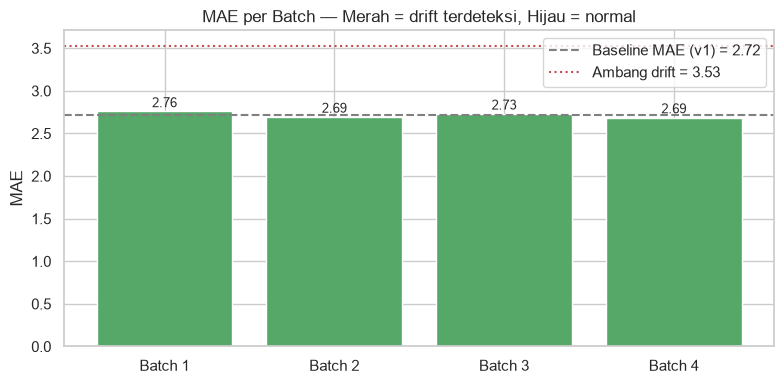

In [23]:
batch_labels = [f"Batch {r['batch']}" for r in drift_log]
batch_mae = [r["performance"]["mae"] for r in drift_log]
drift_flags = [r["drift_detected"] for r in drift_log]

plt.figure(figsize=(8, 4))
colors = ["#C44E52" if d else "#55A868" for d in drift_flags]
bars = plt.bar(batch_labels, batch_mae, color=colors)
plt.axhline(PROD_BASELINE_MAE, linestyle="--", color="gray", label=f"Baseline MAE (v1) = {PROD_BASELINE_MAE:.2f}")
plt.axhline(PROD_BASELINE_MAE * MAE_THRESHOLD_RATIO, linestyle=":", color="#C44E52",
            label=f"Ambang drift = {PROD_BASELINE_MAE * MAE_THRESHOLD_RATIO:.2f}")
for bar, val in zip(bars, batch_mae):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.2f}", ha="center", fontsize=9)
plt.ylabel("MAE"); plt.title("MAE per Batch — Merah = drift terdeteksi, Hijau = normal")
plt.legend(); plt.tight_layout(); plt.show()

# 9. Memuat Model Aktif (untuk Serving via API)

`active_version.json` menunjuk ke checkpoint yang sedang live. REST API cukup
membaca file ini saat startup (atau tiap kali menerima request) untuk tahu
model & encoding maps mana yang harus dipakai, serta versi & waktu update
untuk mengisi field `model_version` dan `last_updated` pada response.

In [24]:
with open(MODEL_REGISTRY_DIR / "active_version.json") as f:
    active_info = json.load(f)

print("Versi model aktif:", active_info["active_version"])
print("Terakhir diperbarui:", active_info["updated_at"])

loaded_model = joblib.load(MODEL_REGISTRY_DIR / active_info["active_version"] / "model.pkl")
loaded_maps = joblib.load(MODEL_REGISTRY_DIR / active_info["active_version"] / "encoding_maps.pkl")

X_sample = assemble_features(test_df.head(5), loaded_maps)
sample_pred = loaded_model.predict(X_sample)
print("Contoh prediksi risk_score:", np.round(sample_pred, 2))

Versi model aktif: v4
Terakhir diperbarui: 2026-08-07T03:00:44.205360+00:00
Contoh prediksi risk_score: [25.69 62.03 36.13 76.44 51.84]
